# Data visualization

## What is data visualization?

Data visualization is the visual representation of information or data to uncover and communicate patterns and insights. At its core, its purpose is to inform and enlighten, either yourself or others. While there is a long history of representing information in graphic form (see for instance the [Turin papyrus map](<http://www.eeescience.utoledo.edu/faculty/harrell/egypt/turin papyrus/harrell_papyrus_map_text.htm>)), its combination with statistics to support decision making really took off in the 18th and 19th centuries (see for instance [John Snow](https://www.rcseng.ac.uk/library-and-publications/library/blog/mapping-disease-john-snow-and-cholera/), who used maps to identify the source of a cholera outbreak, and [Florence Nightingale](https://www.scientificamerican.com/article/how-florence-nightingale-changed-data-visualization-forever/), who used statistical graphics to reform healthcare practices), and was later formalized by statisticians like the Americans John Tukey and Edward Tufte.

As you have seen in the [previous section](1:descriptive_statistics:graphical_representations), graphical representations that encode the data with symbols are essential in statistics. Building on the idea that well-designed graphics are our simplest and most powerful tool to analyze and communicate statistical information, [Tufte (2001)](https://www.edwardtufte.com/book/the-visual-display-of-quantitative-information) defined six principles of graphical excellence:

> Graphical excellence is the well-designed presentation of interesting data – a matter of *substance*, of *statistics*, and of *design*.
> 
> Graphical excellence consists of complex ideas communicated with clarity, precision, and efficiency.
> 
> Graphical excellence is that which gives to the viewer the greatest number of ideas in the shortest time with the least ink in the smallest space.
> 
> Graphical excellence is nearly always multivariate.
> 
> And graphical excellence requires telling the truth about the data.  

## How to design a figure?

Building on Tufte's work, [Rougier et al. (2014)](https://doi.org/10.1371/journal.pcbi.1003833) provide ten rules to improve figure design:
  1. Know Your Audience
  2. Identify Your Message
  3. Adapt the Figure to the Support Medium
  4. Captions Are Not Optional
  5. Do Not Trust the Defaults
  6. Use Color Effectively
  7. Do Not Mislead the Reader
  8. Avoid “Chartjunk”
  9. Message Trumps Beauty
  10. Get the Right Tool

Efficient communication is central to both Tufte’s principles and Rougier et al.’s rules: the goal is not to overwhelm stakeholders with data, but to help them understand what the data mean.

### Chart types

Not all types of charts or graphics are equal on this path to understanding: As you have seen in the [previous section](1:descriptive_statistics:graphical_representations), different types of charts have different objectives:
  * Bar charts and histograms display the distribution of categorical and numerical variables, respectively.
  * Box plots let us compare groups and numerical variables by displaying some key summary statistics of their distributions.
  * Scatter plots display the relationship between at least two numerical variables.
  * Pair plots use multiple histograms and scatter plots in a 2D grid to compare and analyze the relationship between multiple numerical variables at once.
  * Heat maps use colors in a 2D grid to highlight differences in magnitude between different data or measures; a common example is a correlation matrix displaying Pearson correlation coefficients.

In addition, two other chart types are particularly useful when working with geodata:
  * Line charts display data points connected by line segments to highlight a change in value, e.g., over time for a time series or over depth for a well log.
  * Maps display vector or raster data in their geographical context, i.e., over space based on a given coordinate reference system.

But many more types of charts exist. The [Financial Times' Visual Vocabulary](https://github.com/Financial-Times/chart-doctor/tree/main/visual-vocabulary) lists the main ones:

<iframe src="https://mozilla.github.io/pdf.js/web/viewer.html?file=https://raw.githubusercontent.com/Financial-Times/chart-doctor/main/visual-vocabulary/Visual-vocabulary-en.pdf" style="height: 600px; width: 100%; margin-bottom: 1em;" title="Financial Times' Visual Vocabulary"></iframe>

The [Data Viz Project](https://datavizproject.com/) is another library of data visualizations that includes descriptions and examples of many chart types. [From Data to Viz](https://www.data-to-viz.com/) on the other hand offers a more interactive workflow to select a chart type depending on the data and objective, as well as examples in various programming languages (including Python).

### Anatomy of a figure

In general, all charts follow a similar format: a figure made of axes that represent the coordinate system in which the data are displayed ({numref}`figure {number} <part-a_data-viz_anatomy-figure>`). Each axis has a label describing what is being plotted (e.g., a variable), and ticks with their labels (and sometimes a grid) to serve as reference points when interpreting the figure. The data themselves can be encoded as points or markers, lines, polygons, etc depending on the type of chart. A legend can be added to describe multiple groups of data, although direct annotation is often more efficient. Figures must have either a title or a caption to convey what the figure is about (i.e., what its key message is), and potentially where the data come from (i.e., their source).

````{figure} ../../figures/part-a_data-viz_anatomy-figure.svg
---
name: part-a_data-viz_anatomy-figure
width: 15cm
align: center
---
Elements that make a figure and Matplotlib's functions that control them (image from [matplotlib.org/stable/gallery/showcase/anatomy.html](https://matplotlib.org/stable/gallery/showcase/anatomy.html)).
````

Two essential concepts need to be kept in mind when adding elements (or not) to a figure:
  * The data-ink ratio, a concept defined by [Tufte (2001)](https://www.edwardtufte.com/book/the-visual-display-of-quantitative-information) (related to rule 8 of [Rougier et al. (2014)](https://doi.org/10.1371/journal.pcbi.1003833)) as:
    ```{math}
    \begin{split}
        \text{data-ink ratio} &= \frac{\text{data-ink}}{\text{total ink used to print the graphic}}\\[1ex]
        &= \text{proportion of a graphic's ink devoted to the} \\
        &\quad \text{non-redundant display of data-information} \\[1ex]
        &= 1 - \text{proportion of a graphic that can be erased} \\
        &\quad \text{without loss of data-information}
    \end{split}
    ```
    While Tufte has sometimes taken it to an extreme minimalism, some non-data elements are fine when they facilitate interpretation or enhance understanding (e.g., grid lines along a time series can help to visualize thresholds). All in all, the data-ink ratio is a conceptual guideline rather than a strict rule to maximize at all costs.

  * Visual hierarchy, which consists in arranging and designing elements to create an order of importance and to guide reading a figure. This can be done by creating contrast between elements, by changing their size, weight, type, or color (including transparency). Usually, changing at least two of those elements is enough to create clear contrast. For instance, a large bold font can be used to guide the eye to the title first, then a smaller font for the axis labels, and an even smaller, non-bold font for the tick labels. Similarly, larger markers or thicker lines can be used to draw attention to specific data.

### Customizing a figure in Matplotlib

Now let's have a look at applying those concepts in Matplotlib. First, we need to import NumPy and Matplotlib:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

With NumPy, we can create some synthetic porosity data based on a log-normal distribution:

In [16]:
np.random.seed(42)
data = np.random.lognormal(mean=-2.5, sigma=0.5, size=1512)

This is what the distribution looks like with Matplotlib's default style:

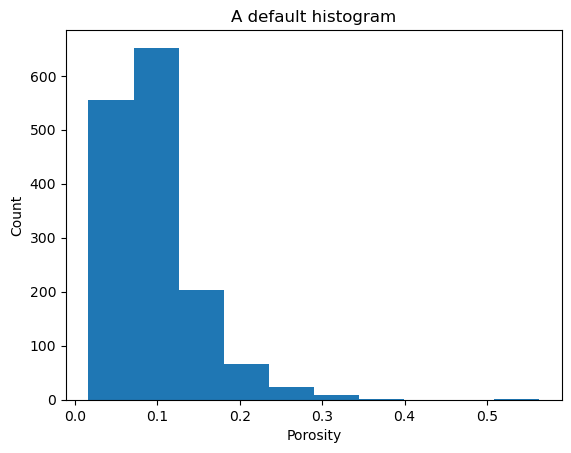

In [30]:
plt.hist(data)
plt.title('A default histogram')
plt.xlabel('Porosity')
plt.ylabel('Count');

Switching to [Matplotlib's axis interface](https://matplotlib.org/stable/api/index.html#matplotlib-interfaces), we can change about anything to customize the figure, like so:

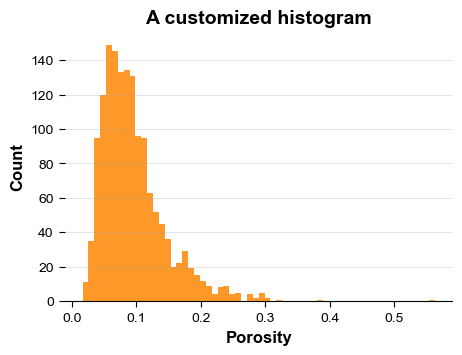

In [41]:
# Create a figure, an axis, and change the figure size (in inches)
fig, ax = plt.subplots(figsize=(5, 3.5))

# Add the histogram to the axis
ax.hist(data, bins=60, color='#fe9929')

# Remove all the spines around the axis except the bottom one
ax.spines[['right', 'left', 'top']].set_visible(False)
# Modify the ticks' style
ax.tick_params(length=4, width=0.8, pad=4, labelsize=10, labelfontfamily='Arial')
# Add a grid for the y-axis only
ax.grid(True, axis='y', color='#9aa0a6', alpha=0.5, linewidth=0.4)

# Add a title
ax.set_title('A customized histogram', fontsize=14, fontweight='bold', fontfamily='Arial')
# add the axis labels
ax.set_xlabel('Porosity', fontsize=12, fontweight='bold', fontfamily='Arial', labelpad=4)
ax.set_ylabel('Count', fontsize=12, fontweight='bold', fontfamily='Arial', labelpad=4);

If you want to learn more about making figure with Matplotib, you can take a look at Nicolas Rougier's book *Scientific Visualization: Python + Matplotlib*, freely available [here](https://github.com/rougier/scientific-visualization-book).

## How to manage colors?

### The issue with colors

How we see objects results from the interaction of multiple elements:
  * A light source, which potentially emits light at specific wavelengths.
  * The objects themselves, which reflect only specific wavelengths of the incident light.
  * The environment around the objects, which reflects specific wavelengths itself.
  * Our eyes, which collect light from all this environment and turn it into an electrical signal.
  * Our brain, which reconstitutes an image based on the signal transmitted from the eyes but also from our own expectations.

So colors do not exist as such: they are interpretations by our brain of different wavelengths of light. And while we tend to consider that we all see colors in the same way, your representation of a specific color is probably different from mine. All in all, this representation depends on two main elements:
  * The context, because the background actually perturbs how we process colors. This has given rise to many optical illusions based on colors and color contrasts ({numref}`e.g., figure {number} <part-a_data-viz_illusion_adelson-1995>`). So interpreting colored-coded data, in maps for instance, is not always as neutral and objective as we might think.
  * Our own biology, because some of us have a lower ability to distinguish some colors, which is called color blindness. About 8 % of men and 0.5 % of women are colorblind, and some may not even know about it. The most common forms of colorblindness are linked to red and green, and complete colorblindness remains rare.

````{figure} ../../figures/part-a_data-viz_illusion_adelson-1995.jpg
---
name: part-a_data-viz_illusion_adelson-1995
width: 11cm
align: center
---
The checker shadow illusion of Edward Adelson: while square A looks darker than square B, they have the same color. You can check that for yourself in [this animation](https://upload.wikimedia.org/wikipedia/commons/9/93/Optical_illusion_greysquares.gif) (image from [persci.mit.edu/gallery/checkershadow/download](https://persci.mit.edu/gallery/checkershadow/download)).
````

The rainbow colormap is a good example of the subjectivity of interpreting colors and its impact. A colormap is an array defining the set of colors used to color-code some data. The rainbow colormap uses the colors in the spectrum of visible light, ordered by wavelength, and remains the default colormap in many software programs. What makes it stand out is that the receptors in our eyes have different sensitivities to different wavelengths. So it is not perceptually uniform: changes in the data will be perceived differently depending on where we are on the colormap. This explains why some people like to use it: it has some stark contrasts that make some features stand out. But those features might come from our interpretation of colors, not from real patterns in the data ({numref}`e.g., figure {number} <modeling_rainbow>`). And since it relies on so many colors, colorblindness can have a huge impact on interpreting data color-coded with a rainbow colormap.

````{figure} https://i0.wp.com/s-ink.org/wp-content/uploads/101-Modelling-Visualisation-Colour-Fabio-Crameri.png
---
name: modeling_rainbow
width: 16cm
align: center
---
Example of geodynamic simulations displayed with a rainbow colormap and with perceptually uniform colormaps (image from [s-ink.org/effective-visualisation-geodynamic-modelling](https://s-ink.org/effective-visualisation-geodynamic-modelling)).
````

### Designing accurate and accessible figures

Knowing how subjective color interpretation can be, it is always good to use a dual encoding of data with colors and symbols whenever possible (e.g., a plain blue line and a red dashed line to show two different variables or datasets &ndash; with proper annotations to explain which is which &ndash; or [contour lines](https://agilescientific.com/blog/2017/12/14/no-more-rainbows) on a map). But that does not mean that you have to stay away from using colors only: more and more colormaps are being designed to be perceptually uniform while still showing a range of colors (Matplotlib has [its own](https://matplotlib.org/stable/users/explain/colors/colormaps.html), but [many](https://colorcet.holoviz.org/) [other](https://www.fabiocrameri.ch/colourmaps) [exist](https://matplotlib.org/cmocean)). Perceptually uniform colormaps ensure that equal changes in data correspond to equal perceptual changes in color.

Different colormaps should be used depending on the properties of the variables of interest and of the data:
  * Sequential colormaps have a color gradient in one direction, usually in lightness (from bright to dark or the other way around). They are used for numerical variables.
  * Diverging colormaps have a color gradient in two directions, usually in lightness as well (often from dark to bright to dark). They are used for numerical variables that have a meaningful middle value, which can be zero (e.g., temperature), 50% (e.g., probability), a target (e.g., heat production), etc.
  * Cyclic colormaps have the same color at the beginning and at the end, often with a symmetric middle point. They are used for directional variables (e.g., wind direction).
  * Categorical colormaps have multiple colors, sometimes with a different lightness to ensure that they are colorblind-friendly. They are used for categorical variables.

When picking a colormap, it is also important to think about how your audience will interpret the color in relation with the variables being displayed. For instance, the diverging colormap going from blue to white to red is often used to represent temperatures on the Celsius scale, in which case the middle should be 0°C, negative temperatures should be blue, positive temperatures should be red. Reversing the scale would only be misleading.

As mentioned at the end of the first paragraph, Matplotlib has a [wide range of colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html), and many more sets are available online ([here](https://sronpersonalpages.nl/~pault) is another one). [Colorbrewer](https://colorbrewer2.org) is also a very useful resource if you need some inspiration to pick colors. [Viz Palette](https://projects.susielu.com/viz-palette) is another useful resource that lets you check whether a set of colors is difficult to distinguish, including for colorblind people. You can also use a [colorblindness simulator](https://daltonlens.org/colorblindness-simulator) to see how your figure would look to people with color vision deficiencies. It is also always good to check how your figure appears when converted to grayscale.

Keep in mind that accessibility also goes beyond colors: typography also matters (mainly font type and text size), and need to be adapted depending on the audience and the communication medium (e.g., in general font size needs to be larger for a presentation, where people are typically quite far from the screen, than on a report).

## Where to find examples?

As mentioned in the previous subsection, the [Data Viz Project](https://datavizproject.com/) and [From Data to Viz](https://www.data-to-viz.com/) have some examples of different chart types. Many news organizations invest heavily in data visualization, making them excellent sources of high-quality, real-world examples (see for instance [The New York Times](https://www.nytimes.com/column/whats-going-on-in-this-graph)). [Our World in Data](https://ourworldindata.org/) also has a large range of graphics illustrating how to visualize different data.